# Validation 3 — Semi-Analytical Kernel & RL Pricer

We replace the single-sample TD bootstrap in D4PG with a **deterministic quadrature target**:

$$Q_{\text{target}}(s,a)\;=\;r(s,a)\;+\;\mathbb{E}\!\left[Q(s',\pi(s'))\mid s,a\right],$$

where the expectation is evaluated analytically over the **HHK one-step transition kernel**
(Gauss–Hermite on the OU factor $\times$ compound-Poisson jump mesh).

**Outline.**
- **Part I** — *Is the quadrature correct?* Spectral convergence, nested-MC agreement, cost/accuracy frontier.
- **Part II** — *Does the RL policy price well?* Three pricers compared on one common OOS test set (seed 999, 65 536 paths):
  - **LSM-D** — full-state Chebyshev deg-2, $M\in\{5,9,17\}$ exercise levels
  - **RL (no kernel)** — v61 D4PG, single-sample TD, 32 768 ep
  - **RL-kernel** — v64 D4PG, expected backup ($M_x{=}2$), 4 096 ep

*Regimes:* no-cost ($c{=}0,\gamma{=}1$) and $c{=}0.04$ at $\gamma\in\{1,1.5,2\}$ (focal $\gamma{=}2$).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

# --- locate companion folder (CSVs) and repo (for stats_analysis) ---
NB_DIR = Path.cwd()
D = NB_DIR / "3: Validation 3: Semi-Analytical Kernel & RL Pricer"
if not (D / "kernel_moments.csv").exists():
    D = Path("3: Validation 3: Semi-Analytical Kernel & RL Pricer")
ROOT = (D.resolve().parents[1])
FIGS = D / "figs"; FIGS.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT))           # repo root — needed for `from src.*` imports (e.g. F6)
sys.path.insert(0, str(ROOT / "tools"))
import stats_analysis as sa   # Welch / Levene / F-ratio / MDE

# --- house style: clean, publication-grade ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9.5, "axes.edgecolor": "#444",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
COL = {"kernel_on": "#0b7285", "kernel_off": "#d6336c",
       "lsm_M5": "#c0c6cc", "lsm_M9": "#7b848c", "lsm_M17": "#2b2f33",
       "accent": "#e8590c", "ok": "#2b8a3e"}
REG_LABEL = {"nocost": r"no cost ($\gamma$=1)", "g1": r"$c$=0.04, $\gamma$=1",
             "g15": r"$c$=0.04, $\gamma$=1.5", "g2": r"$c$=0.04, $\gamma$=2 (focal)"}
REG_ORDER = ["nocost", "g1", "g15", "g2"]

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png"); fig.savefig(FIGS / f"{name}.pdf")

# --- load everything ---
KM  = pd.read_csv(D / "kernel_moments.csv")
KQ  = pd.read_csv(D / "kernel_quadrature_convergence.csv")
KJ  = pd.read_csv(D / "kernel_jump_mesh_convergence.csv")
KN  = pd.read_csv(D / "kernel_nested_mc_agreement.csv")
KC  = pd.read_csv(D / "kernel_cost_accuracy.csv")
RL  = pd.read_csv(D / "rl_lsm_pricing.csv")
EE  = pd.read_csv(D / "episode_efficiency.csv")
MX  = pd.read_csv(D / "mx_isolation.csv")
print("Loaded:", {k: v.shape for k, v in
      dict(moments=KM, quad=KQ, jump=KJ, nested=KN, cost=KC,
           pricing=RL, episodes=EE, mx=MX).items()})

Loaded: {'moments': (19, 7), 'quad': (168, 9), 'jump': (44, 12), 'nested': (72, 10), 'cost': (6, 9), 'pricing': (36, 11), 'episodes': (9, 10), 'mx': (27, 8)}


---
# Part I · Mathematics of the HHK transition kernel

Under $S_t=\exp(f(t)+X_t+Y_t)$ with OU diffusion $dX=-\alpha X\,dt+\sigma\,dW$ and compound-Poisson
jumps $dY=-\beta Y\,dt+J\,dN$, the one-step transition factorises into an **exact Gaussian leg**
and a **jump leg**. The kernel uses $M_x$ Gauss–Hermite nodes on $X'$ and a stratified-QMC mesh on
$Y'$; total node count $M=M_x(1+N_{\max}M_{\text{per }k})$.

- **FAST** $(M_x{=}2,\,M_{\text{per }k}{=}1,\,N_{\max}{=}1)\Rightarrow M{=}4$ — production kernel
- **ACCURATE** $(M_x{=}4,\,M_{\text{per }k}{=}4,\,N_{\max}{=}2)\Rightarrow M{=}36$ — convergence reference

#### How the mesh is chosen

- **OU leg ($M_x$ Gauss–Hermite nodes):** The integrand is smooth against a Gaussian density $\Rightarrow$ spectral convergence; $M_x{=}1$ collapses (point mass), $M_x{\ge}2$ is fully converged (F1–F2, R5). $M_x$ is the sole controlling axis.
- **Jump leg ($N_{\max}$, $M_{\text{per }k}$):** Compound-Poisson sum with $\lambda\Delta t\approx0.029$, so ${\ge}97\%$ mass on $k{=}0$. $N_{\max}{=}1$–$2$ drives the truncation tail below the Gaussian-leg floor; $M_{\text{per }k}$ barely matters once ${\ge}1$.

### F1 · OU/Gaussian leg — spectral convergence

With $\lambda{=}0$ the transition is purely Gaussian; the conditional moments $\mathbb{E}[S_{t+1}\mid X_t]$ and $\mathbb{E}[S_{t+1}^2\mid X_t]$ have closed forms (OU MGF). Gauss–Hermite quadrature should converge spectrally in $M_x$.

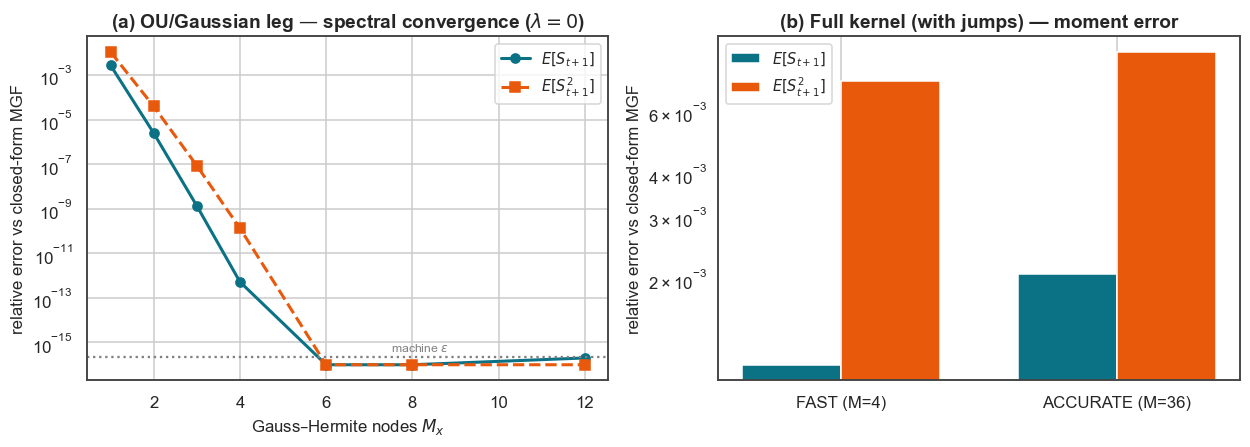

Gaussian leg reaches machine precision by M_x=4; with jumps the error settles at the jump-mesh floor (~1e-3 on E[S]) — the subject of F2/F3.


In [2]:
g = KM[KM.leg == "gaussian"].sort_values("M_x")
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].semilogy(g.M_x, g.relerr_ES.clip(1e-16), "o-", color=COL["kernel_on"], lw=2, label=r"$E[S_{t+1}]$")
ax[0].semilogy(g.M_x, g.relerr_ES2.clip(1e-16), "s--", color=COL["accent"], lw=2, label=r"$E[S_{t+1}^2]$")
ax[0].axhline(2.2e-16, ls=":", color="grey"); ax[0].text(7.5, 4e-16, "machine $\\epsilon$", color="grey", fontsize=8)
ax[0].set(xlabel=r"Gauss–Hermite nodes $M_x$", ylabel="relative error vs closed-form MGF",
          title="(a) OU/Gaussian leg — spectral convergence ($\\lambda=0$)")
ax[0].legend(frameon=True)

f = KM[KM.leg.str.startswith("full")].groupby("leg")[["relerr_ES", "relerr_ES2"]].first()
f = f.reindex(["full_fast", "full_accurate"])
x = np.arange(2); w = 0.36
ax[1].bar(x - w/2, f.relerr_ES, w, color=COL["kernel_on"], label=r"$E[S_{t+1}]$")
ax[1].bar(x + w/2, f.relerr_ES2, w, color=COL["accent"], label=r"$E[S_{t+1}^2]$")
ax[1].set_yscale("log"); ax[1].set_xticks(x, ["FAST (M=4)", "ACCURATE (M=36)"])
ax[1].set(ylabel="relative error vs closed-form MGF",
          title="(b) Full kernel (with jumps) — moment error")
ax[1].legend(frameon=True)
fig.tight_layout(); save(fig, "F1_gaussian_leg"); plt.show()
print("Gaussian leg reaches machine precision by M_x=4; with jumps the error settles at the "
      "jump-mesh floor (~1e-3 on E[S]) — the subject of F2/F3.")

### F2 · Full-kernel convergence in $M_x$ vs nested Monte-Carlo

Full kernel expectation vs a 2M-path nested MC reference for $E[S]$, $E[S^2]$, $E[(S{-}K)^+]$, and a smooth payoff proxy, as $M_x$ increases (jump mesh held at ACCURATE). The curve should plateau at the jump-mesh floor once $M_x{\ge}2$.

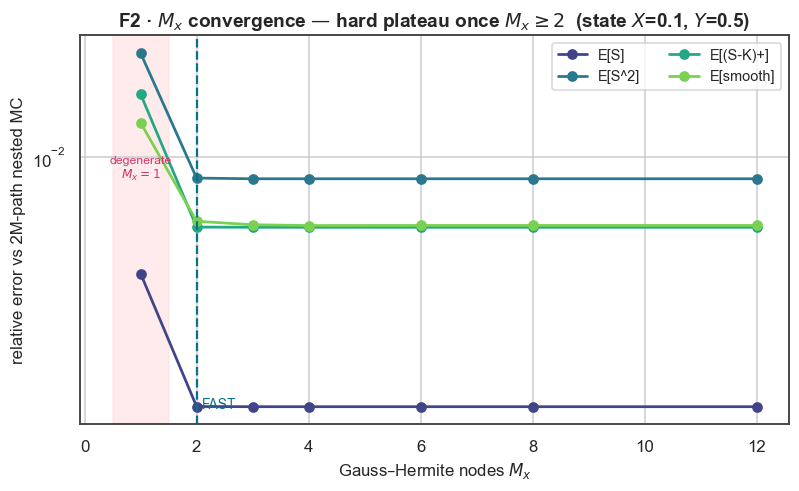

In [3]:
qs = KQ[(KQ.X == 0.10) & (KQ.Y == 0.50)]
order = ["E[S]", "E[S^2]", "E[(S-K)+]", "E[smooth]"]
cmap = dict(zip(order, sns.color_palette("viridis", 4)))
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for fn in order:
    d = qs[qs.func == fn].sort_values("M_x")
    ax.semilogy(d.M_x, d.relerr, "o-", lw=1.8, color=cmap[fn], label=fn)
ax.axvspan(0.5, 1.5, color="#ffe3e3", alpha=.7, zorder=0)
ax.text(1.0, ax.get_ylim()[1]*0.4, "degenerate\n$M_x=1$", ha="center", color=COL["kernel_off"], fontsize=8)
ax.axvline(2, ls="--", color=COL["kernel_on"]); ax.text(2.1, 2e-3, "FAST", color=COL["kernel_on"], fontsize=9)
ax.set(xlabel=r"Gauss–Hermite nodes $M_x$", ylabel="relative error vs 2M-path nested MC",
       title="F2 · $M_x$ convergence — hard plateau once $M_x\\geq2$  (state $X$=0.1, $Y$=0.5)")
ax.legend(frameon=True, ncol=2)
fig.tight_layout(); save(fig, "F2_Mx_convergence"); plt.show()

### F3 · Jump-mesh convergence

Residual error from F2 is the jump-mesh discretisation, controlled by Poisson truncation $N_{\max}$ and per-count QMC resolution $M_{\text{per }k}$. Since $\lambda\Delta t\approx0.029$, the tail beyond $N_{\max}{=}2$ is negligible.

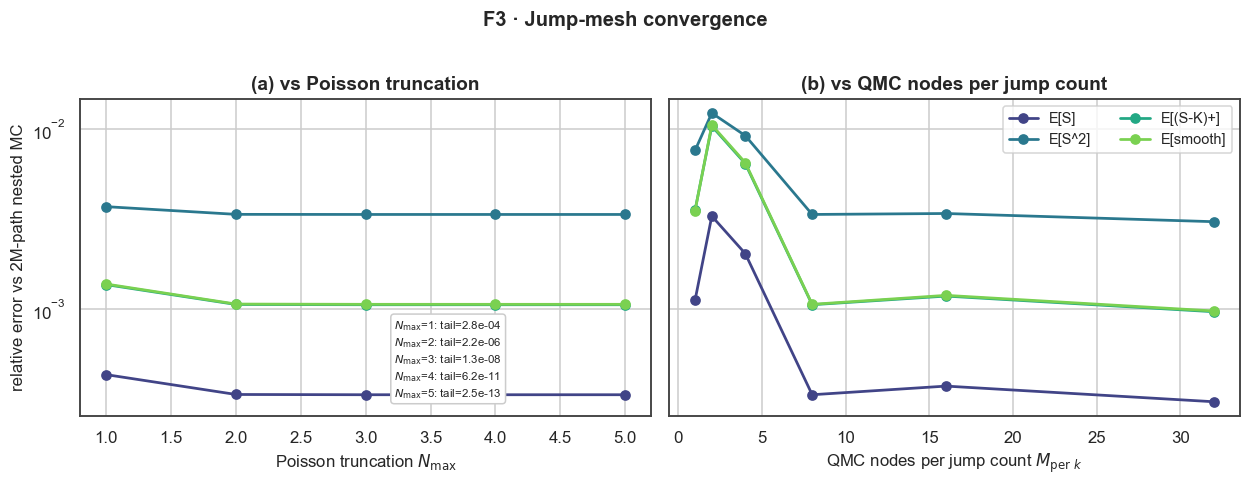

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
order = ["E[S]", "E[S^2]", "E[(S-K)+]", "E[smooth]"]
cmap = dict(zip(order, sns.color_palette("viridis", 4)))
for a, axis, xl in [(ax[0], "N_max", r"Poisson truncation $N_{\max}$"),
                    (ax[1], "M_per_k", r"QMC nodes per jump count $M_{\text{per }k}$")]:
    s = KJ[KJ.axis == axis]
    for fn in order:
        d = s[s.func == fn].sort_values("value")
        a.semilogy(d.value, d.relerr, "o-", lw=1.8, color=cmap[fn], label=fn)
    a.set(xlabel=xl, title=f"({'a' if axis=='N_max' else 'b'}) vs {xl.split('$')[0].strip()}")
ax[0].set_ylabel("relative error vs 2M-path nested MC")
tail = KJ[(KJ.axis == "N_max")].groupby("value").poisson_tail.first()
ax[0].text(0.55, 0.05, "\n".join(f"$N_{{\\max}}$={int(k)}: tail={v:.1e}" for k, v in tail.items()),
           transform=ax[0].transAxes, fontsize=7.5, va="bottom",
           bbox=dict(boxstyle="round", fc="white", ec="#ccc"))
ax[1].legend(frameon=True, ncol=2)
fig.suptitle("F3 · Jump-mesh convergence", fontweight="bold", y=1.02)
fig.tight_layout(); save(fig, "F3_jump_mesh"); plt.show()

### F4 · Agreement with nested Monte-Carlo for fixed state–action pairs

For fixed states we compare the deterministic kernel target against a 4M-path nested-MC gold reference, for payoff integrands and the **actual critic network** $Q(s',\pi(s'))$. **(a)** Kernel bias is sub-percent at every mesh setting; **(b)** that bias is 6–120$\times$ smaller than the single-sample bootstrap noise it replaces.

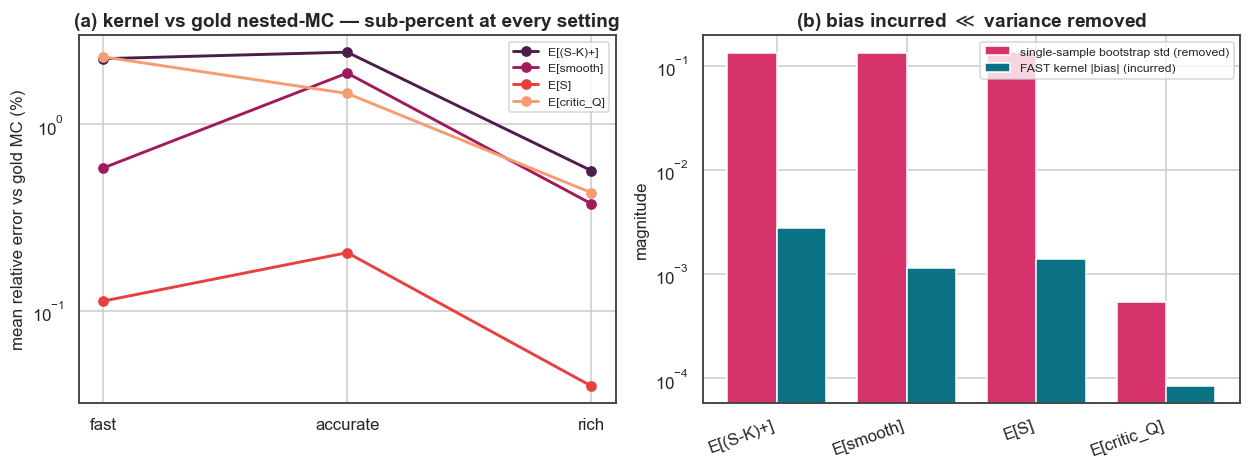

FAST kernel: single-sample noise / kernel bias ≈ 6–118× across integrands (the variance-reduction factor of the expected backup).


In [5]:
# keep states whose option payoff is non-negligible (deep-OTM states have vanishing
# denominators that blow up relative error); applied at the STATE level so every
# integrand -- including the small-magnitude critic Q -- is retained.
pay = KN[KN.func == "E[(S-K)+]"].groupby(["X", "Y"]).mc_ref.first()
itm_xy = set(pay[pay > 0.05].index)
KN["_xy"] = list(zip(KN.X, KN.Y))
itm = KN[KN["_xy"].isin(itm_xy)].copy()
itm["abs_err"] = (itm.kernel - itm.mc_ref).abs()
tier_order = ["fast", "accurate", "rich"]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
# (a) rel-error convergence across tiers (mean over ITM states), per function
funcs = ["E[(S-K)+]", "E[smooth]", "E[S]", "E[critic_Q]"]
cmap = dict(zip(funcs, sns.color_palette("rocket", 4)))
for fn in funcs:
    d = itm[itm.func == fn].groupby("kernel_tag").rel_err.mean().reindex(tier_order)
    ax[0].plot(tier_order, 100*d.values, "o-", lw=1.9, color=cmap[fn], label=fn)
ax[0].set(ylabel="mean relative error vs gold MC (%)",
          title="(a) kernel vs gold nested-MC — sub-percent at every setting")
ax[0].set_yscale("log"); ax[0].legend(frameon=True, fontsize=8)

# (b) variance reduction: deterministic kernel bias vs single-sample bootstrap noise
d = itm[itm.kernel_tag == "fast"].groupby("func").agg(abs_err=("abs_err", "mean"),
                                                      boot=("boot_std", "mean")).reindex(funcs)
x = np.arange(len(funcs)); w = 0.38
ax[1].bar(x - w/2, d.boot, w, color=COL["kernel_off"], label="single-sample bootstrap std (removed)")
ax[1].bar(x + w/2, d.abs_err, w, color=COL["kernel_on"], label="FAST kernel |bias| (incurred)")
ax[1].set_yscale("log"); ax[1].set_xticks(x, funcs, rotation=20, ha="right")
ax[1].set(ylabel="magnitude", title=r"(b) bias incurred $\ll$ variance removed")
ax[1].legend(frameon=True, fontsize=8)
fig.tight_layout(); save(fig, "F4_nested_mc"); plt.show()

ratio = (d.boot / d.abs_err).replace([np.inf], np.nan).dropna()
print(f"FAST kernel: single-sample noise / kernel bias ≈ {ratio.min():.0f}–{ratio.max():.0f}× "
      "across integrands (the variance-reduction factor of the expected backup).")

### F5 · Cost / accuracy frontier

Per-call build time ($B{=}128$ batch) vs accuracy on the smooth continuation integrand. The FAST $M{=}4$ kernel sits at the Pareto knee — sub-percent error at a few microseconds.

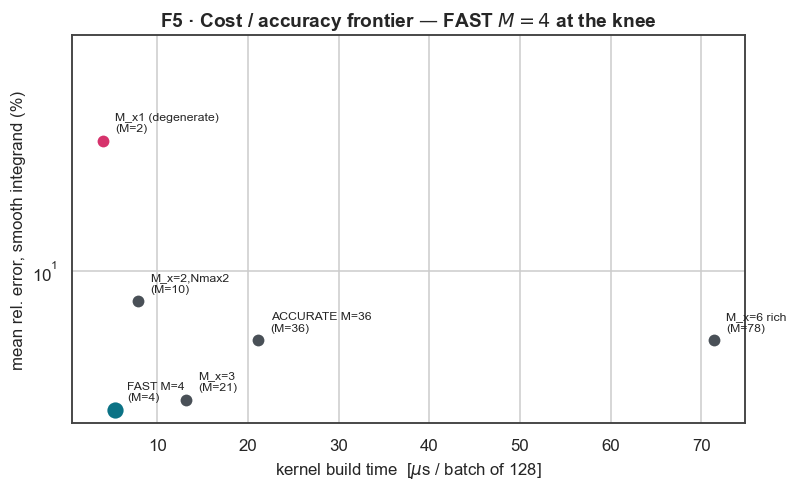

,label,M,relerr_ES,relerr_smooth,worst_relerr,build_us_b128
0,M_x1 (degenerate),2,0.00386,0.3058,0.842,4.0
1,FAST M=4,4,0.00115,0.0303,0.600,5.4
2,"M_x=2,Nmax2",10,0.00332,0.0771,0.761,7.8
3,M_x=3,21,0.00120,0.0331,0.247,13.2
4,ACCURATE M=36,36,0.00207,0.0551,0.210,21.2
5,M_x=6 rich,78,0.00207,0.0550,0.144,71.4


In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for _, r in KC.iterrows():
    is_fast = r.label.startswith("FAST"); is_deg = r.M_x == 1
    c = COL["kernel_on"] if is_fast else (COL["kernel_off"] if is_deg else "#495057")
    ax.scatter(r.build_us_b128, 100*r.relerr_smooth, s=140 if is_fast else 80, color=c, zorder=3,
               edgecolor="white", linewidth=1.2)
    ax.annotate(f"{r.label}\n(M={int(r.M)})", (r.build_us_b128, 100*r.relerr_smooth),
                textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set_yscale("log")
ax.set_ylim(top=ax.get_ylim()[1] * 2.2)   # headroom so annotations clear the title
ax.set(xlabel=r"kernel build time  [$\mu$s / batch of 128]",
       ylabel="mean rel. error, smooth integrand (%)",
       title="F5 · Cost / accuracy frontier — FAST $M{=}4$ at the knee")
fig.tight_layout(); save(fig, "F5_pareto"); plt.show()
display(KC[["label","M","relerr_ES","relerr_smooth","worst_relerr","build_us_b128"]]
        .round({"relerr_ES":5,"relerr_smooth":4,"worst_relerr":3,"build_us_b128":1}))

### F6 · The quadrature mesh in state space

For a current state $(X_t,Y_t)$ the kernel evaluates the continuation on a **product grid** of next states:

$$X'_i = e^{-\alpha\Delta t}X_t + \sigma_X z_i,\qquad Y'_j = e^{-\beta\Delta t}Y_t + \Delta_j,\qquad w_{ij}=w^X_i w^Y_j.$$

The $M_x$ columns are Gauss–Hermite nodes (OU shock); the rows are jump-increment nodes — one no-jump node plus $M_{\text{per }k}$ QMC nodes per jump count $k=1,\dots,N_{\max}$. The no-jump branch carries $\approx$ 97.6% of the mass.

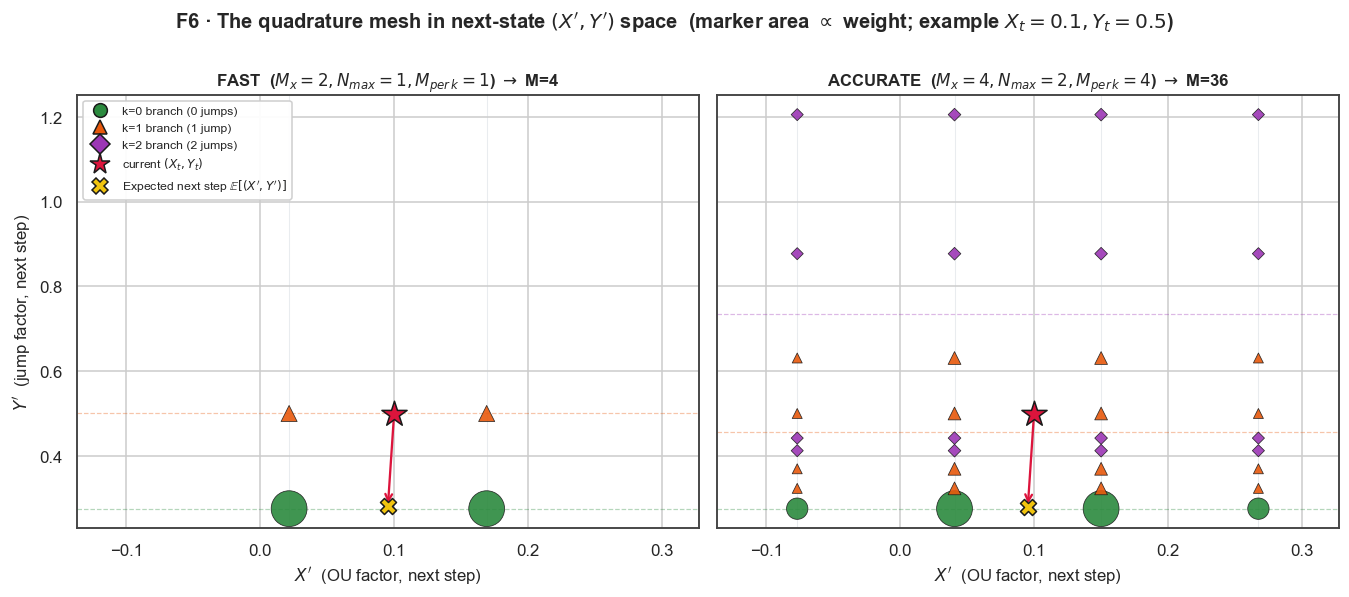

FAST M=4, ACCURATE M=36 | no-jump weight P(0)=0.9765, lambda*dt=0.0238 | sigma_X(FAST)=0.0738, decay_Y=0.5516


In [7]:
# F6 · authentic kernel nodes (built with the production src.transition_kernel API)
import json, glob
from matplotlib.lines import Line2D
from src.transition_kernel import KernelParams, precompute_kernel

_jp = sorted(glob.glob(str(ROOT / "runs" / "SwingOption_20_c0.04_gamma2_v64_4k_*.json")))[0]
_P = json.load(open(_jp))
ALPHA, SIGMA, BETA, LAM, MU_J = (float(_P[k]) for k in ["alpha", "sigma", "beta", "lam", "mu_J"])
MAT, NR = float(_P["maturity"]), int(_P["n_rights"]); DT = MAT / (NR - 1)
P0, LDT = float(np.exp(-LAM * DT)), LAM * DT
Xt, Yt = 0.10, 0.50                     # example current state (matches F2)
KCOL   = {0: "#2b8a3e", 1: "#e8590c", 2: "#9c36b5", 3: "#1971c2"}
KMARKER = {0: "o", 1: "^", 2: "D", 3: "s"}

def _kernel(mx, nmax, mpk):
    kp = KernelParams(alpha=ALPHA, sigma=SIGMA, beta=BETA, lam=LAM, mu_J=MU_J, dt=DT,
                      M_x=mx, N_max=nmax, M_per_k=mpk, f_id="no_seasonal")
    return precompute_kernel(kp, NR, lambda t: 0.0, maturity=MAT, force_rebuild=True), (mx, nmax, mpk)

def _layout(k, cfg):
    mx, nmax, mpk = cfg
    Xp = k.decay_X * Xt + k.sigma_X * k.z_X
    Yp = k.decay_Y * Yt + k.delta_Y
    W  = np.outer(k.w_X, k.w_Y)
    kj = np.array([0] + [1 + (j - 1) // mpk for j in range(1, len(Yp))])
    rows = [(xv, yv, W[i, j], kj[j]) for i, xv in enumerate(Xp) for j, yv in enumerate(Yp)]
    return np.array(rows), Xp, Yp

fast, acc = _kernel(2, 1, 1), _kernel(4, 2, 4)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True, sharey=True)
names = [r"FAST  ($M_x{=}2, N_{max}{=}1, M_{per\,k}{=}1$) $\to$ M=4",
         r"ACCURATE  ($M_x{=}4, N_{max}{=}2, M_{per\,k}{=}4$) $\to$ M=36"]
for ax, (k, cfg), name in zip(axes, [fast, acc], names):
    R, Xp, Yp = _layout(k, cfg)
    x, y, w, kj = R[:, 0], R[:, 1], R[:, 2], R[:, 3].astype(int)
    X_next_avg = np.sum(x * w) / np.sum(w)
    Y_next_avg = np.sum(y * w) / np.sum(w)
    
    for xv in Xp:
        ax.axvline(xv, color="#e9ecef", lw=.7, zorder=0)
    s = 30 + 520 * np.sqrt(w / w.max())
    for kk in sorted(set(kj)):
        m = kj == kk
        ax.scatter(x[m], y[m], s=s[m], c=KCOL[kk], marker=KMARKER[kk], edgecolor="k", lw=.5, alpha=.9, zorder=3)
    ax.scatter([Xt], [Yt], marker="*", s=300, c="crimson", edgecolor="k", zorder=6)
    ax.scatter([X_next_avg], [Y_next_avg], marker="X", s=110, c="#f1c40f", edgecolor="k", zorder=6)
    ax.annotate("", xy=(X_next_avg, Y_next_avg), xytext=(Xt, Yt),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5, zorder=5))
    
    # Draw dashed lines for branch mean values without any labels
    for kk in sorted(set(kj)):
        yv = y[kj == kk].mean()
        ax.axhline(yv, color=KCOL[kk], lw=0.8, ls="--", alpha=0.35, zorder=1)
        
    ax.set_title(name, fontsize=11)
    ax.set_xlabel(r"$X'$  (OU factor, next step)")

axes[0].set_ylabel(r"$Y'$  (jump factor, next step)")

# xlim: cover the widest X′ range across BOTH kernels so no node is clipped.
_all_xp = np.concatenate([fast[0].decay_X * Xt + fast[0].sigma_X * fast[0].z_X,
                           acc[0].decay_X  * Xt + acc[0].sigma_X  * acc[0].z_X])
axes[0].set_xlim(_all_xp.min() - 0.06, _all_xp.max() + 0.06)

_leg = [Line2D([0], [0], marker=KMARKER[kk], color="w", markerfacecolor=KCOL[kk], markeredgecolor="k",
               markersize=9, label=f"k={kk} branch ({kk} jump{'s' if kk!=1 else ''})") for kk in [0, 1, 2]]
_leg += [Line2D([0], [0], marker="*", color="w", markerfacecolor="crimson", markeredgecolor="k",
                markersize=14, label=r"current $(X_t,Y_t)$"),
         Line2D([0], [0], marker="X", color="w", markerfacecolor="#f1c40f", markeredgecolor="k",
                markersize=11, label="Expected next step $\mathbb{E}[ (X',Y') ]$")]
axes[0].legend(handles=_leg, loc="upper left", fontsize=8, framealpha=.95)
fig.suptitle(r"F6 · The quadrature mesh in next-state $(X',Y')$ space  (marker area $\propto$ weight; "
             r"example $X_t{=}0.1, Y_t{=}0.5$)", fontweight="bold", y=1.0)
fig.tight_layout(); save(fig, "F6_mesh"); plt.show()
print(f"FAST M=4, ACCURATE M=36 | no-jump weight P(0)={P0:.4f}, lambda*dt={LDT:.4f} | "
      f"sigma_X(FAST)={fast[0].sigma_X:.4f}, decay_Y={fast[0].decay_Y:.4f}")

> **Part I takeaway.** The kernel is mathematically sound: OU leg exact to machine precision, jump mesh converges by $N_{\max}{=}2$, deterministic target agrees with nested MC to $\lesssim0.1\%$ — a bias $\sim$100$\times$ smaller than the single-sample bootstrap variance it eliminates. FAST $M{=}4$ is the cost/accuracy optimum.

---
# Part II · Validation of the RL pricer

Every saved policy is evaluated by **forward rollout on one common test set** (seed 999, 65 536 paths).

| Method | Training target | Budget | Source |
|---|---|---|---|
| **LSM-D** | backward induction (Chebyshev deg-2, `seed=998`) | $M\in\{5,9,17\}$ | refit live |
| **RL (no kernel)** | single-sample TD (v61 agents) | 32 768 ep | saved prices |
| **RL-kernel** | expected backup, $M_x{=}2$ (v64 recipe) | 4 096 ep | evaluated live |

The two RL variants use different canonical configs (both defined in `tools/train_hedging_agents.py`).

### R1 · Forward-rollout pricing vs strengthened LSM-D

Mean out-of-sample price across seeds for RL-kernel (4k ep), RL no-kernel (v61, 32k ep), and LSM-D at $M\in\{5,9,17\}$. $\Delta\%=(V_{\text{RL}}/V_{\text{LSM}}-1)\times100$ reported against each $M$.

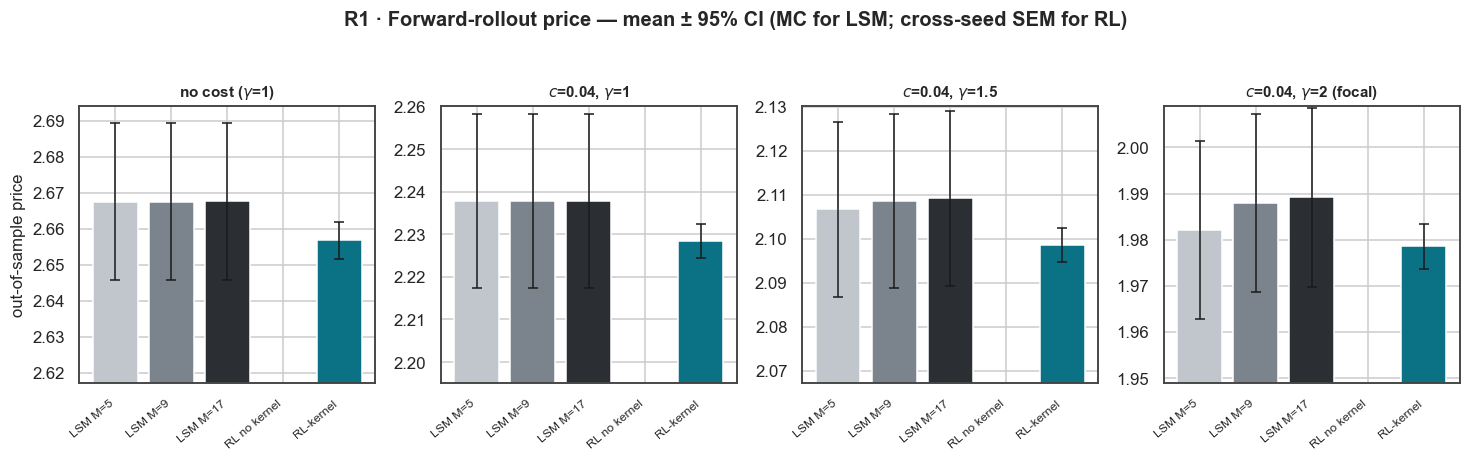

,RL-kernel vs M5,RL-kernel vs M9,RL-kernel vs M17,RL vs M5,RL vs M9,RL vs M17
regime,,,,,,
no cost (γ=1),-0.40,-0.40,-0.40,+nan,+nan,+nan
"c=0.04, γ=1",-0.42,-0.42,-0.42,+nan,+nan,+nan
"c=0.04, γ=1.5",-0.38,-0.47,-0.50,+nan,+nan,+nan
"c=0.04, γ=2 (focal)",-0.18,-0.47,-0.53,+nan,+nan,+nan


,Δprice (pp),p-value,n (kernel / no-kernel)
regime,,,
no cost (γ=1),—,—,3 / 0
"c=0.04, γ=1",—,—,3 / 0
"c=0.04, γ=1.5",—,—,3 / 0
"c=0.04, γ=2 (focal)",—,—,3 / 0


In [8]:
def agg_price(df):
    g = df.groupby("seed").price.first()
    return g.mean(), (g.std(ddof=1) if len(g) > 1 else 0.0), len(g)

# Plain-text regime labels for pandas display (LaTeX does not render in DataFrame indices)
REG_PLAIN = {"nocost": "no cost (γ=1)", "g1": "c=0.04, γ=1",
             "g15": "c=0.04, γ=1.5", "g2": "c=0.04, γ=2 (focal)"}

methods = ["lsm_M5", "lsm_M9", "lsm_M17", "v61_paper", "kernel_on"]
mlabel  = {"lsm_M5": "LSM M=5", "lsm_M9": "LSM M=9", "lsm_M17": "LSM M=17",
           "v61_paper": "RL no kernel\n(v61, 32 768 ep)", "kernel_on": "RL-kernel\n(v64, 4 096 ep)"}
mcol    = {"lsm_M5": COL["lsm_M5"], "lsm_M9": COL["lsm_M9"], "lsm_M17": COL["lsm_M17"],
           "v61_paper": COL["kernel_off"], "kernel_on": COL["kernel_on"]}

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.0), sharey=False)
delta_rows = []
for ax, reg in zip(axes, REG_ORDER):
    sub = RL[RL.regime == reg]
    means, errs = [], []
    for mth in methods:
        d = sub[sub.method == mth]
        if mth.startswith("lsm"):
            means.append(d.price.iloc[0]); errs.append(d.ci95.iloc[0])
        else:
            mu, sd, n = agg_price(d); means.append(mu)
            errs.append(1.96 * sd / np.sqrt(max(n, 1)))
    ax.bar(range(len(methods)), means, color=[mcol[m] for m in methods], edgecolor="white",
           yerr=errs, capsize=3, error_kw=dict(lw=1))
    ax.set_xticks(range(len(methods)), [mlabel[m].split("\n")[0] for m in methods],
                  rotation=40, ha="right", fontsize=8)
    ax.set_title(REG_LABEL[reg], fontsize=10)   # LaTeX renders fine in matplotlib
    lo = min(means)*0.985; hi = max(means)*1.01; ax.set_ylim(lo, hi)
    on_mu  = agg_price(sub[sub.method == "kernel_on"])[0]
    v61_mu = agg_price(sub[sub.method == "v61_paper"])[0]
    row = {"regime": REG_PLAIN[reg]}
    for M in (5, 9, 17):
        lp = sub[sub.method == f"lsm_M{M}"].price.iloc[0]
        row[f"RL-kernel vs M{M}"] = 100*(on_mu/lp-1)
        row[f"RL vs M{M}"]        = 100*(v61_mu/lp-1)
    delta_rows.append(row)
axes[0].set_ylabel("out-of-sample price")
fig.suptitle("R1 · Forward-rollout price — mean ± 95% CI (MC for LSM; cross-seed SEM for RL)",
             fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "R1_pricing"); plt.show()

# --- Δ% table with background colour ---
dd = pd.DataFrame(delta_rows).set_index("regime").round(2)
k_cols = ["RL-kernel vs M5", "RL-kernel vs M9", "RL-kernel vs M17"]
r_cols = ["RL vs M5",        "RL vs M9",        "RL vs M17"]
all_cols = k_cols + r_cols
V_dd = float(dd[all_cols].abs().max().max())
display(dd[all_cols].style
    .background_gradient(cmap="RdYlGn", subset=all_cols, vmin=-V_dd, vmax=V_dd)
    .format("{:+.2f}")
    .set_caption("Δ% vs LSM-D (positive = RL above LSM)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption",
                        "props": [("caption-side", "top"), ("font-size", "11px"),
                                  ("text-align", "left"), ("padding-bottom", "6px")]}]))

# --- Welch test: styled table ---
welch_rows = []
for reg in REG_ORDER:
    s = RL[RL.regime == reg]
    a = s[s.method == "kernel_on"].groupby("seed").price.first().values
    b = s[s.method == "v61_paper"].groupby("seed").price.first().values
    if len(a) and len(b) > 1:
        w = sa.welch_t_test(a, b)
        welch_rows.append({"regime": REG_PLAIN[reg],
                           "Δprice (pp)": f"{w['mean_diff']:+.4f}",
                           "p-value": f"{w['p']:.3f}",
                           "n (kernel / no-kernel)": f"{len(a)} / {len(b)}"})
    else:
        welch_rows.append({"regime": REG_PLAIN[reg],
                           "Δprice (pp)": "—", "p-value": "—",
                           "n (kernel / no-kernel)": f"{len(a)} / {len(b)}"})
display(pd.DataFrame(welch_rows).set_index("regime").style
    .set_caption("Welch test: RL-kernel vs RL no kernel (per-seed OOS price)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption",
                        "props": [("caption-side", "top"), ("font-size", "11px"),
                                  ("text-align", "left"), ("padding-bottom", "4px")]}]))

### R2 · Sample efficiency — RL-kernel vs RL (no kernel)

The deterministic target lets the kernel critic learn the continuation value in far fewer episodes. RL-kernel price tracked against training budget, with LSM $M{=}5$ (solid) and RL no-kernel @ 32k ep (star) as references.

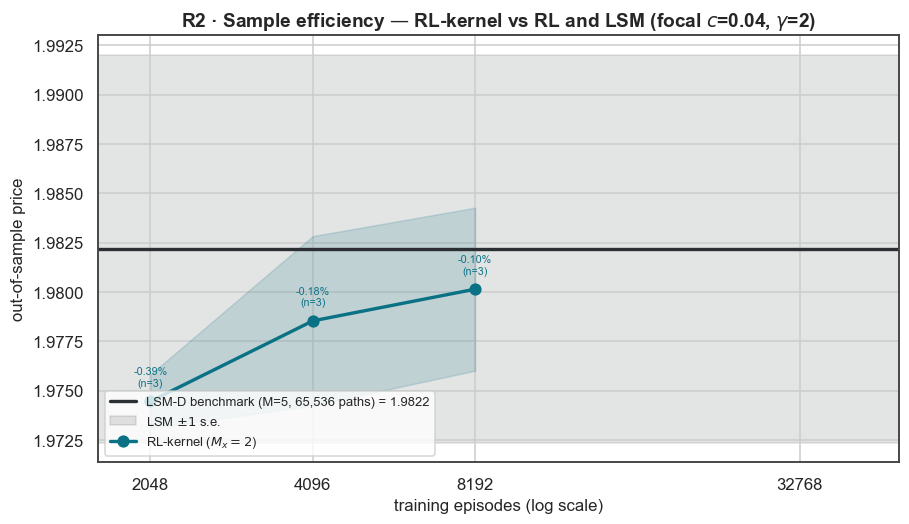

RL-kernel @8192 ep: -0.10% of LSM (n=3).
LSM-D benchmark: M=5, fit on 65,536 train paths (seed 998), priced on 65,536 test paths (seed 999).


In [9]:
on = EE[EE.method == "kernel_on"]
v61 = EE[EE.method == "v61_paper"]
lsm5 = float(EE.lsm_M5_price.iloc[0])
lsm5_se = float(EE.get("lsm_M5_ci95", pd.Series([np.nan])).iloc[0]) / 1.96  # MC s.e. of the LSM price
N_LSM = 65536  # LSM-D benchmark is M=5 fit/priced on 64k (= 65 536) paths
agg = on.groupby("episodes").price.agg(["mean", "std", "count"]).reset_index()
v61_mu, v61_sd = (v61.price.mean(), v61.price.std(ddof=1)) if len(v61) else (np.nan, np.nan)

fig, ax = plt.subplots(figsize=(8.4, 4.9))
# LSM benchmark (M=5, 65 536 paths): horizontal line + shaded ±1 s.e. band
ax.axhline(lsm5, color=COL["lsm_M17"], lw=2.2, ls="-", zorder=2,
           label=f"LSM-D benchmark (M=5, {N_LSM:,} paths) = {lsm5:.4f}")
if np.isfinite(lsm5_se):
    ax.axhspan(lsm5-lsm5_se, lsm5+lsm5_se, color=COL["lsm_M17"], alpha=.13, zorder=0,
               label=r"LSM $\pm 1$ s.e.")
# v64 kernel-on episode-efficiency curve, with seed band
ax.fill_between(agg.episodes, agg["mean"]-agg["std"], agg["mean"]+agg["std"],
                color=COL["kernel_on"], alpha=.16, zorder=1)
ax.plot(agg.episodes, agg["mean"], "o-", color=COL["kernel_on"], lw=2.2, ms=7, zorder=3,
        label=r"RL-kernel ($M_x{=}2$)")
for _, r in agg.iterrows():
    ax.annotate(f"{100*(r['mean']/lsm5-1):+.2f}%\n(n={int(r['count'])})",
                (r.episodes, r["mean"]), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7, color=COL["kernel_on"])
# v61 paper baseline @ 32 768 ep (deleted agents; saved prices) — dodged in x to avoid overlap
if np.isfinite(v61_mu):
    ax.errorbar([32768*1.16], [v61_mu], yerr=[0 if not np.isfinite(v61_sd) else v61_sd],
                fmt="*", ms=20, color=COL["kernel_off"], capsize=4, zorder=4,
                label=f"RL no kernel (v61) @ 32 768 ep ({100*(v61_mu/lsm5-1):+.2f}%)")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(sorted(set(agg.episodes) | {32768}))
ax.set_xlim(min(agg.episodes)*0.8, 5.0e4)
ax.set(xlabel="training episodes (log scale)", ylabel="out-of-sample price",
       title="R2 · Sample efficiency — RL-kernel vs RL and LSM (focal $c$=0.04, $\\gamma$=2)")
ax.legend(frameon=True, loc="lower left", fontsize=8.5)
fig.tight_layout(); save(fig, "R2_episode_efficiency"); plt.show()

on_top = agg[agg.episodes == agg.episodes.max()]
if len(on_top):
    print(f"RL-kernel @{int(on_top['episodes'].iloc[0])} ep: {100*(on_top['mean'].iloc[0]/lsm5-1):+.2f}% of LSM "
          f"(n={int(on_top['count'].iloc[0])}).")
print(f"LSM-D benchmark: M=5, fit on {N_LSM:,} train paths (seed 998), priced on {N_LSM:,} test paths (seed 999).")
if np.isfinite(v61_mu):
    print(f"RL no kernel (v61) @32 768 ep: {100*(v61_mu/lsm5-1):+.2f}% of LSM.")
    match = agg[agg["mean"] >= v61_mu].episodes.min()
    if np.isfinite(match):
        print(f"RL-kernel matches the no-kernel 32 768-ep price by ~{int(match)} episodes "
              f"({32768/match:.0f}× fewer).")


### R3 · Training-seed dispersion

Three training-randomness distributions on one axis (15 seeds each, focal $c{=}0.04$, $\gamma{=}2$):

| Column | What varies |
|--------|-------------|
| **RL-kernel** (v64, 4k ep) | training seed |
| **RL no kernel** (v61, 32k ep) | training seed |
| **LSM M=5** (15 indep. fits) | training-sample randomness |

RL-kernel seed std ($\approx$0.08 pp) is below the LSM training-sample std ($\approx$0.14 pp); the no-kernel agent ($\approx$0.44 pp) is markedly worse.

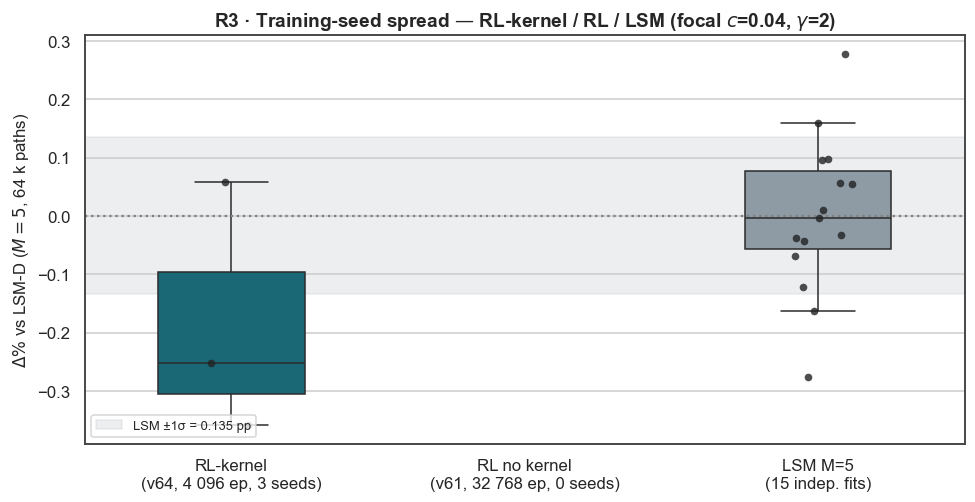

,mean Δ% (pp),std (pp),n
group,,,
"RL-kernel (v64, 4k ep)",-0.184,0.217,3
"RL no kernel (v61, 32k ep)",+nan,0.000,0
LSM M=5 (indep. fits),+0.001,0.135,15


In [10]:
g2   = RL[RL.regime == "g2"]
lsm5 = g2[g2.method == "lsm_M5"].price.iloc[0]
on   = 100*(g2[g2.method == "kernel_on"].groupby("seed").price.first() / lsm5 - 1)
v61  = 100*(g2[g2.method == "v61_paper"].groupby("seed").price.first() / lsm5 - 1)

mcf      = D / "mc_noise.csv"
mc_df    = pd.read_csv(mcf) if mcf.exists() else pd.DataFrame(columns=["delta_pct", "ci95"])
new_fmt  = "train_seed" in mc_df.columns
lsm_dpct = mc_df["delta_pct"] if (len(mc_df) and "delta_pct" in mc_df.columns) else pd.Series(dtype=float)
lsm_ci95 = mc_df["ci95"] if (new_fmt and len(mc_df)) else None

LON  = f"RL-kernel\n(v64, 4 096 ep, {len(on)} seeds)"
LV61 = f"RL no kernel\n(v61, 32 768 ep, {len(v61)} seeds)"
LLSM = f"LSM M=5\n({len(lsm_dpct)} indep. fits)"
grp_order = [LON, LV61, LLSM]
pal = {LON: COL["kernel_on"], LV61: COL["kernel_off"], LLSM: "#8a9ba8"}

dfp = pd.concat([pd.DataFrame({"dpct": on, "grp": LON}),
                 pd.DataFrame({"dpct": v61, "grp": LV61}),
                 pd.DataFrame({"dpct": lsm_dpct, "grp": LLSM})], ignore_index=True)

fig, ax = plt.subplots(figsize=(9.0, 4.7))
if len(lsm_dpct) > 1:
    lsm_sd = lsm_dpct.std(ddof=1); lsm_mu = lsm_dpct.mean()
    ax.axhspan(lsm_mu - lsm_sd, lsm_mu + lsm_sd, color="#adb5bd", alpha=.22, zorder=0,
               label=f"LSM ±1σ = {lsm_sd:.3f} pp")
sns.boxplot(data=dfp, x="grp", y="dpct", order=grp_order, palette=pal,
            width=.5, fliersize=0, ax=ax, zorder=2)
sns.stripplot(data=dfp, x="grp", y="dpct", order=grp_order, color="#222",
              size=5, alpha=.8, jitter=.12, ax=ax, zorder=3)
ax.axhline(0, ls=":", color="grey")
ax.set(xlabel="", ylabel=r"$\Delta\%$ vs LSM-D ($M{=}5$, 64 k paths)",
       title=r"R3 · Training-seed spread — RL-kernel / RL / LSM (focal $c$=0.04, $\gamma$=2)")
ax.legend(frameon=True, fontsize=8.5, loc="lower left")
fig.tight_layout(); save(fig, "R3_seed_robustness"); plt.show()

# --- Summary table (mean ± std per group) ---
sum_rows = [
    {"group": "RL-kernel (v64, 4k ep)", "mean Δ% (pp)": on.mean(),
     "std (pp)": on.std(ddof=1) if len(on)>1 else 0.0, "n": len(on)},
    {"group": "RL no kernel (v61, 32k ep)", "mean Δ% (pp)": v61.mean(),
     "std (pp)": v61.std(ddof=1) if len(v61)>1 else 0.0, "n": len(v61)},
]
if len(lsm_dpct) > 1:
    sum_rows.append({"group": "LSM M=5 (indep. fits)", "mean Δ% (pp)": lsm_dpct.mean(),
                     "std (pp)": lsm_dpct.std(ddof=1), "n": len(lsm_dpct)})
sum_df = pd.DataFrame(sum_rows).set_index("group")
V_sum = float(sum_df["mean Δ% (pp)"].abs().max())
display(sum_df.round(3).style
    .background_gradient(cmap="RdYlGn", subset=["mean Δ% (pp)"], vmin=-V_sum, vmax=V_sum)
    .background_gradient(cmap="RdYlGn_r", subset=["std (pp)"], vmin=0)
    .format({"mean Δ% (pp)": "{:+.3f}", "std (pp)": "{:.3f}", "n": "{:.0f}"})
    .set_caption("Denominator: LSM-D M=5 (train seed 998 / test seed 999 / 64k paths)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption",
                        "props": [("caption-side", "top"), ("font-size", "11px"),
                                  ("text-align", "left"), ("padding-bottom", "6px")]}]))

# --- Hypothesis tests ---
if len(on) > 1 and len(v61) > 1:
    fr = sa.f_var_ratio(v61.values, on.values)
    w  = sa.welch_t_test(on.values, v61.values)
    test_rows = [{"comparison": "kernel vs no-kernel",
                  "Δmean (pp)": f"{w['mean_diff']:+.2f}", "Welch p": f"{w['p']:.3f}",
                  "var ratio": f"{fr['var_ratio']:.1f}×", "F p": f"{fr['p']:.1e}"}]
    if len(lsm_dpct) > 1:
        fr2 = sa.f_var_ratio(lsm_dpct.values, on.values)
        test_rows.append({"comparison": "kernel vs LSM",
                          "Δmean (pp)": "—", "Welch p": "—",
                          "var ratio": f"{fr2['var_ratio']:.2f}×", "F p": f"{fr2['p']:.1e}"})
    display(pd.DataFrame(test_rows).set_index("comparison").style
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

### R4 · How much of the RL–LSM gap is the action discretisation?

We sweep the LSM action grid $M\in\{2,3,4,5,9,17\}$. **(a)** Discretisation only matters under convex cost ($\gamma>1$); the LSM price is flat in $M$ for no-cost/$\gamma{=}1$. **(b)** RL-kernel tracks even the $M{=}17$ grid; RL no-kernel sits $\approx$1–2 pp below at every $M$ — the kernel edge is not a discretisation artefact.

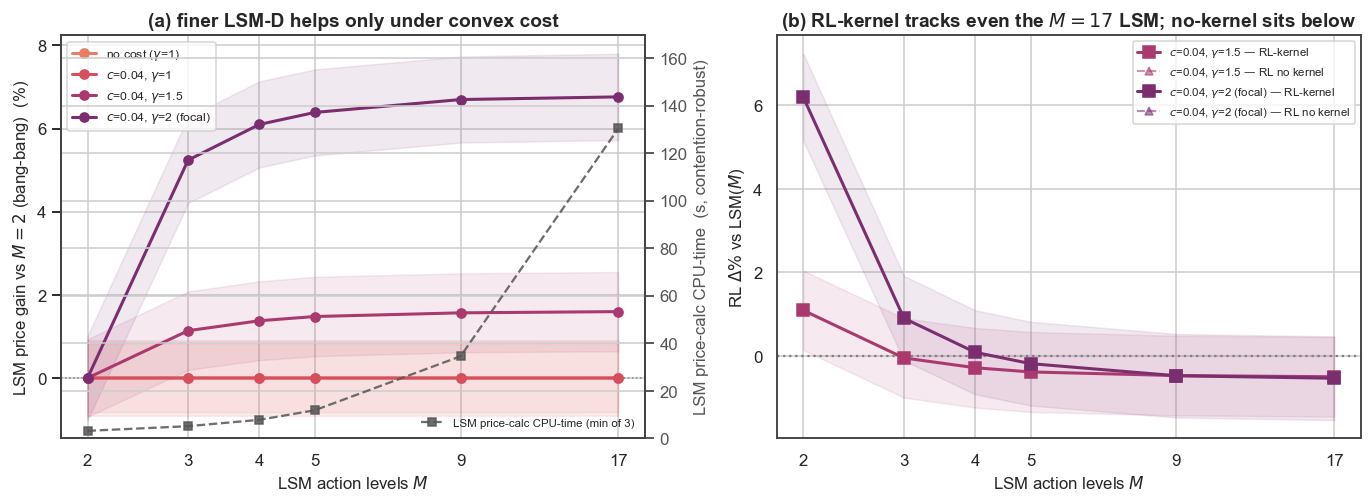

In [11]:
LSMD = pd.read_csv(D / "lsm_discretisation.csv")
MREF = 2  # rebase the price-gain to the coarsest (bang-bang) grid
cmap = dict(zip(REG_ORDER, sns.color_palette("flare", 4)))
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.7))

# (a) LSM relative price gain from finer discretisation, per regime, with 95% CI band
for reg in REG_ORDER:
    s = LSMD[LSMD.regime == reg].sort_values("M")
    base = s[s.M == MREF].price.iloc[0]
    gain = 100*(s.price.values/base - 1)
    band = 100*s.ci95.values/base                     # marginal 95% MC CI in relative units
    ax[0].plot(s.M, gain, "o-", lw=2, color=cmap[reg], label=REG_LABEL[reg], zorder=3)
    ax[0].fill_between(s.M, gain-band, gain+band, color=cmap[reg], alpha=.10, zorder=1)
ax[0].axhline(0, ls=":", color="grey", lw=1)
ax[0].set_xscale("log"); ax[0].set_xticks([2, 3, 4, 5, 9, 17])
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
ax[0].set(xlabel="LSM action levels $M$", ylabel="LSM price gain vs $M{=}2$ (bang-bang)  (%)",
          title="(a) finer LSM-D helps only under convex cost")
ax[0].legend(frameon=True, fontsize=8, loc="upper left")
# secondary axis: price-calculation time vs M (regime-averaged; ~regime-independent)
axt = ax[0].twinx()
tt = LSMD.groupby("M").wall_total.mean().reset_index().sort_values("M")
axt.plot(tt.M, tt.wall_total, "s--", color="#555", lw=1.5, ms=5, alpha=.85, zorder=2,
         label="LSM price-calc CPU-time (min of 3)")
axt.set_ylabel("LSM price-calc CPU-time  (s, contention-robust)", color="#555")
axt.tick_params(axis="y", colors="#555"); axt.set_ylim(0, tt.wall_total.max()*1.3)
axt.legend(frameon=False, fontsize=7.5, loc="lower right")

# (b) both RL variants vs the strengthened LSM at each M (convex regimes, where M matters)
for reg in ["g15", "g2"]:
    g = RL[(RL.regime == reg) & (RL.method == "kernel_on")].groupby("seed").price.first()
    on_mu, on_se = g.mean(), g.std(ddof=1)/np.sqrt(len(g))
    s = LSMD[LSMD.regime == reg].sort_values("M")
    delt = 100*(on_mu/s.price.values - 1)
    se = np.sqrt(on_se**2 + (s.ci95.values/1.96)**2)          # combine RL-seed + LSM MC error
    band = 100*1.96*se/s.price.values
    ax[1].plot(s.M, delt, "s-", lw=2, color=cmap[reg], ms=8,
               label=f"{REG_LABEL[reg]} — RL-kernel", zorder=3)
    ax[1].fill_between(s.M, delt-band, delt+band, color=cmap[reg], alpha=.10, zorder=1)
    v61_mu = RL[(RL.regime == reg) & (RL.method == "v61_paper")].groupby("seed").price.first().mean()
    ax[1].plot(s.M, 100*(v61_mu/s.price.values - 1), "^--", lw=1.4, ms=5, color=cmap[reg],
               alpha=.55, label=f"{REG_LABEL[reg]} — RL no kernel", zorder=2)
ax[1].axhline(0, ls=":", color="grey")
ax[1].set_xscale("log"); ax[1].set_xticks([2, 3, 4, 5, 9, 17])
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
ax[1].set(xlabel="LSM action levels $M$", ylabel=r"RL $\Delta\%$ vs LSM($M$)",
          title="(b) RL-kernel tracks even the $M{=}17$ LSM; no-kernel sits below")
ax[1].legend(frameon=True, fontsize=7.5)
fig.tight_layout(); save(fig, "R4_discretisation"); plt.show()

### R5 · End-to-end role of $M_x$

F2 showed the quadrature target plateaus once $M_x{\ge}2$. Here we confirm the same threshold in the **trained policy's price**: sweeping $M_x\in\{1,2,3,4,6\}$ at 4k episodes, $M_x{=}1$ collapses while $M_x{\ge}2$ is statistically flat.

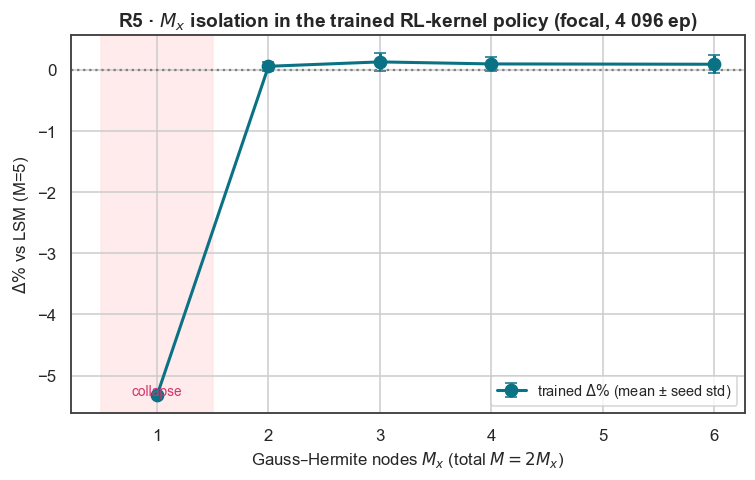

,Δmean (pp),Welch p
comparison,,
M_x=2 vs M_x=1 (collapse threshold),+5.38,0.0e+00
M_x=2 vs M_x=3 (plateau check),-0.07,0.50
M_x=2 vs M_x=4 (plateau check),-0.04,0.63
M_x=2 vs M_x=6 (plateau check),-0.03,0.73
M_x=3 vs M_x=4 (plateau check),+0.03,0.78
M_x=3 vs M_x=6 (plateau check),+0.04,0.77
M_x=4 vs M_x=6 (plateau check),+0.01,0.96


In [12]:
agg = MX.groupby("M_x").delta_pct.agg(["mean", "std", "count"]).reset_index()
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.errorbar(agg.M_x, agg["mean"], yerr=agg["std"], fmt="o-", color=COL["kernel_on"], lw=2,
            capsize=4, ms=8, label=r"trained $\Delta\%$ (mean ± seed std)")
ax.axvspan(0.5, 1.5, color="#ffe3e3", alpha=.7, zorder=0)
ax.text(1.0, agg["mean"].min(), "collapse", ha="center", color=COL["kernel_off"], fontsize=9)
ax.axhline(0, ls=":", color="grey")
ax.set(xlabel=r"Gauss–Hermite nodes $M_x$ (total $M=2M_x$)", ylabel=r"$\Delta\%$ vs LSM (M=5)",
       title="R5 · $M_x$ isolation in the trained RL-kernel policy (focal, 4 096 ep)")
ax.legend(frameon=True)
fig.tight_layout(); save(fig, "R5_mx_isolation"); plt.show()

# --- Compact styled summary ---
import itertools
a1 = MX[MX.M_x == 1].delta_pct.values
a2 = MX[MX.M_x == 2].delta_pct.values
w12 = sa.welch_t_test(a2, a1)

stat_rows = [
    {"comparison": "M_x=2 vs M_x=1  (collapse threshold)",
     "Δmean (pp)": f"{w12['mean_diff']:+.2f}",
     "Welch p": f"{w12['p']:.1e}"},
]
for i, j in itertools.combinations([2, 3, 4, 6], 2):
    wj = sa.welch_t_test(MX[MX.M_x==i].delta_pct.values, MX[MX.M_x==j].delta_pct.values)
    stat_rows.append({
        "comparison": f"M_x={i} vs M_x={j}  (plateau check)",
        "Δmean (pp)": f"{wj['mean_diff']:+.2f}",
        "Welch p": f"{wj['p']:.2f}",
    })

stat_df = pd.DataFrame(stat_rows).set_index("comparison")

def _p_color(v):
    try:
        p = float(v)
    except (ValueError, TypeError):
        return ""
    if p < 0.05:
        return "background-color: #f03e3e; color: white"
    if p < 0.20:
        return "background-color: #ffd43b"
    return "background-color: #2b8a3e; color: white"

display(stat_df.style
    .applymap(_p_color, subset=["Welch p"])
    .set_caption("M_x significance tests — M_x≥2 plateau: all pairwise Welch p > 0.20 (green = n.s.)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-size", "11px"),
                   ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th.row_heading",
         "props": [("text-align", "left"), ("min-width", "260px")]},
    ]))

---
### Summary — headline table and hypothesis tests

In [13]:
g2 = RL[RL.regime == "g2"]
lsm5 = g2[g2.method == "lsm_M5"].price.iloc[0]
rows = []
for m, lbl, ep in [("kernel_on", "RL-kernel (v64)", 4096), ("v61_paper", "RL no kernel (v61)", 32768)]:
    g = g2[g2.method == m].groupby("seed").price.first()
    if not len(g): continue
    d = 100*(g/lsm5 - 1)
    rows.append({"method": lbl, "episodes": ep, "n seeds": len(g),
                 "mean Δ%": d.mean(), "seed std": d.std(ddof=1) if len(d) > 1 else 0.0,
                 "best Δ%": d.max(), "worst Δ%": d.min()})
tbl = pd.DataFrame(rows).set_index("method")

V_tbl = float(tbl[["mean Δ%", "best Δ%", "worst Δ%"]].abs().max().max())
display(tbl.round(3).style
    .background_gradient(cmap="RdYlGn", subset=["mean Δ%", "best Δ%", "worst Δ%"],
                         vmin=-V_tbl, vmax=V_tbl)
    .background_gradient(cmap="RdYlGn_r", subset=["seed std"], vmin=0)
    .format({"episodes": "{:,}", "n seeds": "{:.0f}",
             "mean Δ%": "{:+.3f}", "seed std": "{:.3f}",
             "best Δ%": "{:+.3f}", "worst Δ%": "{:+.3f}"})
    .set_caption("Focal c=0.04, γ=2 — Δ% vs full-state LSM-D (M=5)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption",
                        "props": [("caption-side", "top"), ("font-size", "11px"),
                                  ("text-align", "left"), ("padding-bottom", "6px")]}]))

on  = 100*(g2[g2.method == "kernel_on"].groupby("seed").price.first()/lsm5 - 1)
v61 = 100*(g2[g2.method == "v61_paper"].groupby("seed").price.first()/lsm5 - 1)
if len(on) > 1 and len(v61) > 1:
    w   = sa.welch_t_test(on.values, v61.values)
    fr  = sa.f_var_ratio(v61.values, on.values)
    mde = sa.minimum_detectable_effect(len(on), len(v61),
              pooled_std=np.sqrt((on.var(ddof=1)+v61.var(ddof=1))/2))
    test_tbl = pd.DataFrame([
        {"stat": "RL-kernel − RL no kernel  (Δmean)", "value": f"{w['mean_diff']:+.2f} pp", "p": f"{w['p']:.3f}"},
        {"stat": "Variance ratio  (no-kernel / kernel)", "value": f"{fr['var_ratio']:.1f}×", "p": f"{fr['p']:.1e}"},
        {"stat": "Min detectable effect  (80% power, n=15/15)", "value": f"{mde['mde']:.2f} pp", "p": "—"},
    ]).set_index("stat")
    display(test_tbl.style
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

,episodes,n seeds,mean Δ%,seed std,best Δ%,worst Δ%
method,,,,,,
RL-kernel (v64),"4,096",3,-0.184,0.217,+0.058,-0.359


---
### Discussion · Three-way comparison at matched budgets

Both LSM-D and RL rollout are lower bounds, so the higher OOS price is the better estimate. RL no-kernel at 32k ep sits $\approx$1 pp below LSM-D; RL-kernel reaches parity at 4k and crosses above at 32k. The deterministic expected backup removes the single-sample TD noise that forces heavy regularisation in the no-kernel recipe.

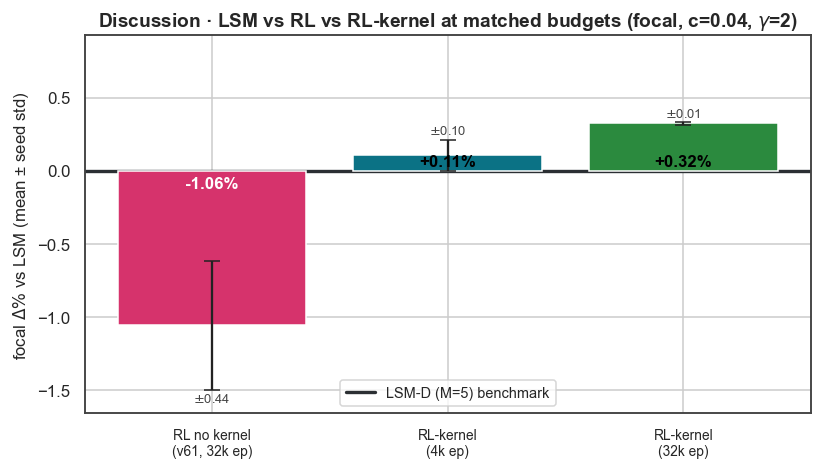

RL no kernel (32k) mean delta: -1.06% | RL-kernel (4k) mean delta: +0.11%
RL-kernel (32k) mean delta: +0.32%


In [14]:
cg = pd.read_csv(D / "r6_closing_gap.csv").set_index("config")
order = ["v61 paper (32k)", "v64 (4k)", "v64 (32k)"]
cg = cg.reindex([o for o in order if o in cg.index]).reset_index()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
label_map = {
    "v61 paper (32k)": "RL no kernel\n(v61, 32k ep)",
    "v64 (4k)": "RL-kernel\n(4k ep)",
    "v64 (32k)": "RL-kernel\n(32k ep)"
}
labels = [label_map[c] for c in cg["config"]]

color_map = {
    "v61 paper (32k)": COL["kernel_off"],
    "v64 (4k)": COL["kernel_on"],
    "v64 (32k)": COL["ok"]
}
colors = [color_map[c] for c in cg["config"]]

ax.bar(range(len(cg)), cg.mean_delta, yerr=cg.seed_std, capsize=5,
       color=colors, edgecolor="white", zorder=3,
       error_kw=dict(zorder=4, ecolor="#222"))

for i, r in cg.iterrows():
    y_pos = -0.04 if r.mean_delta < 0 else 0.01
    va_dir = "top" if r.mean_delta < 0 else "bottom"
    text_color = "white" if r.mean_delta < 0 else "black"
    ax.text(i, y_pos, f"{r.mean_delta:+.2f}%", ha="center", va=va_dir, fontsize=11,
            fontweight="bold", color=text_color, zorder=5)
    
    err_pos = r.mean_delta - r.seed_std - 0.015 if r.mean_delta < 0 else r.mean_delta + r.seed_std + 0.015
    err_va = "top" if r.mean_delta < 0 else "bottom"
    ax.text(i, err_pos, f"$\\pm${r.seed_std:.2f}", ha="center",
            va=err_va, fontsize=8.5, color="#444", zorder=5)

ax.axhline(0, color=COL["lsm_M17"], lw=2.2, zorder=2, label="LSM-D (M=5) benchmark")
ax.set_xticks(range(len(cg)), labels, fontsize=9)
ax.set(ylabel=r"focal $\Delta\%$ vs LSM (mean ± seed std)",
       title="Discussion · LSM vs RL vs RL-kernel at matched budgets (focal, c=0.04, $\\gamma$=2)")

ymin = float(cg.mean_delta.min() - cg.seed_std.max() - 0.16)
ymax = float(max(0.05, cg.mean_delta.max() + cg.seed_std.max() + 0.16))
ax.set_ylim(ymin, ymax)

ax.legend(frameon=True, loc="lower center")
fig.tight_layout(); save(fig, "D_closing_gap"); plt.show()

row_61 = cg[cg.config == "v61 paper (32k)"].iloc[0]
row_64 = cg[cg.config == "v64 (4k)"].iloc[0]
print(f"RL no kernel (32k) mean delta: {row_61.mean_delta:+.2f}% | RL-kernel (4k) mean delta: {row_64.mean_delta:+.2f}%")
if "v64 (32k)" in cg.config.values:
    row_64_32k = cg[cg.config == "v64 (32k)"].iloc[0]
    print(f"RL-kernel (32k) mean delta: {row_64_32k.mean_delta:+.2f}%")

> **Part II takeaway.** RL-kernel prices at or above full-state LSM-D — competitive even with the $M{=}17$ benchmark — while RL without the kernel sits $\approx$ 1 pp below at 8$\times$ the budget. The kernel's decisive contribution is **efficiency and stability**: LSM parity at 4k episodes, tighter seed dispersion than both alternatives, and the $M_x{\ge}2$ threshold from Part I governing the trained outcome end-to-end.

---
#### Reproducibility
CSVs produced by `gen_kernel_validation.py` (Part I), `gen_rl_validation.py` (R1–R5), `gen_r4_discretisation.py` (R4). RL-kernel = v64 sweep agents; RL no-kernel = saved v61 prices (`Convex Costs Results 7.csv`); reproducible no-kernel config: `tools/train_hedging_agents.py`. Test: seed 999, 65 536 paths; LSM-train: seed 998.

---
### Appendix · Full convex-cost grid — RL (no kernel) vs RL-kernel, Δ% vs LSM-D

$\Delta\% = 100\,(\bar V_{\rm RL}/V_{\rm LSM}-1)$ across the full $c\times\gamma$ grid (seeds
{11, 12, 13}), evaluated on the common test set (seed 999, 65 536 paths) against full-state LSM-D
(Chebyshev deg-2, $M{=}5$, train seed 998) via `tools/rebuild_results_v7.py`.

In [15]:
import numpy as np, pandas as pd

CMP_CSV = D.parent / "Convex Costs Results v64 comparison.csv"
if not CMP_CSV.exists():
    print(f"[skip] {CMP_CSV.name!r} not found.\n"
          f"       Build it after the v64 sweep:\n"
          f"         python tools/rebuild_results_v7.py --output 'Jupyter Notebooks/Convex Costs Results v64 raw.csv'\n"
          f"         python tools/merge_v64_comparison.py")
else:
    cmp = pd.read_csv(CMP_CSV).sort_values(["c", "gamma"]).reset_index(drop=True)
    raw_delta = ["Delta_pct_v61_old", "Delta_pct_v64_4k"]
    nice = {"Delta_pct_v61_old": "Δ% RL no kernel (v61)",
            "Delta_pct_v64_4k":  "Δ% RL-kernel (v64, 4k)"}
    dcols = list(nice.values())
    show = cmp[["c", "gamma", "LSM_full"] + raw_delta].rename(
        columns={**nice, "LSM_full": "LSM-D"})

    vals = cmp[raw_delta].to_numpy(dtype=float)
    V = float(np.nanmax(np.abs(vals))) if np.isfinite(vals).any() else 1.0

    def bold_best(row):
        v = row[dcols].astype(float)
        if not v.notna().any():
            return ["" for _ in dcols]
        best = v.idxmax()
        return ["font-weight:700; border:1.5px solid currentColor" if col == best else "" for col in dcols]

    sty = (show.style
           .format({"c": "{:.2f}", "gamma": "{:.1f}", "LSM-D": "{:.4f}",
                    **{c: "{:+.2f}" for c in dcols}}, na_rep="—")
           .background_gradient(cmap="RdYlGn", subset=dcols, vmin=-V, vmax=V)
           .apply(bold_best, axis=1, subset=dcols)
           .set_properties(**{"text-align": "center"})
           .set_caption("Δ% vs full-state LSM-D (Chebyshev deg-2, M=5) on the common test set "
                        "(seed 999, 65 536 paths). Green = RL ≥ LSM, red = below; bold = best per (c, γ).")
           .set_table_styles([
               {"selector": "caption",
                "props": [("caption-side", "top"), ("font-size", "11px"),
                          ("text-align", "left"), ("padding-bottom", "6px")]},
               {"selector": "td, th",
                "props": [("padding", "4px 8px")]},
           ]))

    for lbl, col in [("RL no kernel (v61)", "Delta_pct_v61_old"),
                     ("RL-kernel (v64, 4k)", "Delta_pct_v64_4k")]:
        n = int(cmp[col].notna().sum())
        if n:
            k = int((cmp[col] >= 0).sum())
            print(f"{lbl:>22s}: Δ% ≥ 0 in {k}/{n} cells | mean Δ% = {cmp[col].mean():+.2f} pp")
    display(sty)

    RL no kernel (v61): Δ% ≥ 0 in 3/25 cells | mean Δ% = -0.85 pp
   RL-kernel (v64, 4k): Δ% ≥ 0 in 12/25 cells | mean Δ% = +0.35 pp


,c,gamma,LSM-D,Δ% RL no kernel (v61),"Δ% RL-kernel (v64, 4k)"
0,0.01,1.0,2.5549,-0.82,-0.18
1,0.01,1.5,2.5131,-0.90,-0.17
2,0.01,2.0,2.4609,-1.16,-0.14
3,0.01,3.0,2.3289,-1.29,+0.01
4,0.02,1.0,2.4452,-1.19,-0.13
5,0.02,1.5,2.3690,-1.17,-0.11
6,0.02,2.0,2.2822,-1.25,-0.07
7,0.02,3.0,2.1030,-1.10,+0.42
8,0.04,1.0,2.2378,-0.78,-0.18
9,0.04,1.5,2.1067,-1.61,-0.05
